In [89]:
# Notebook 3: AI Object Detection
# You'll learn: how a pretrained model finds objects in an image.

from ultralytics import YOLO
import cv2
import matplotlib.pyplot as plt

In [91]:
pwd

'/Users/quentin/Desktop/NoBlackBoxes/LastBlackBox/course/versions/ai-workshops/02_vision/_resources/chromebook/notebooks'

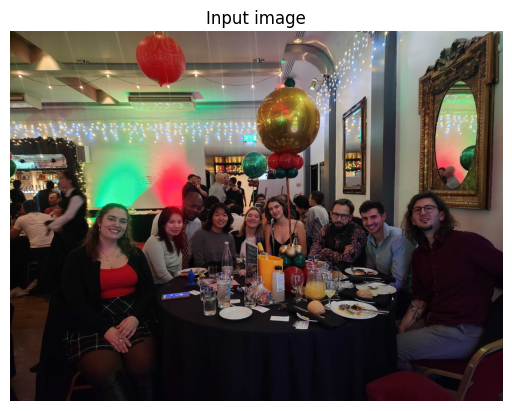

In [92]:
# Load an image
img = cv2.imread("../images/lab_photo.png")

if img is None:
    raise FileNotFoundError("Image not found. Please check the path and try again.")

# Convert BGR to RGB for display
rgb = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)

# Display the image
plt.imshow(rgb)
plt.title("Input image")
plt.axis("off")
plt.show()

In [11]:
# Load a pretrained YOLO model
# This model already knows many everyday objects
model = YOLO("yolov8n.pt")

In [12]:
# Run object detection on the image
results = model(img)


0: 640x640 1 person, 1 sports ball, 2 tennis rackets, 292.6ms
Speed: 2.4ms preprocess, 292.6ms inference, 1.5ms postprocess per image at shape (1, 3, 640, 640)


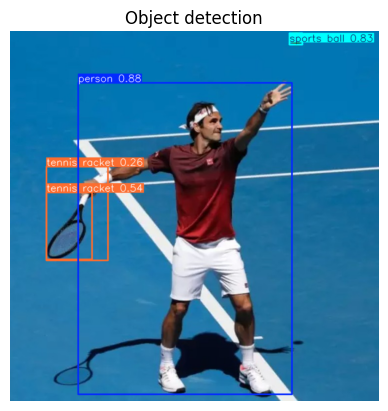

In [13]:
# Draw the predicted boxes and labels on the image
annotated = results[0].plot()

# Convert BGR to RGB for display
annotated = cv2.cvtColor(annotated, cv2.COLOR_BGR2RGB)

plt.imshow(annotated)
plt.title("Object detection")
plt.axis("off")
plt.show()

In [14]:
# Print the detected objects and their confidence scores
for box in results[0].boxes:
    cls_id = int(box.cls[0])
    conf = float(box.conf[0])

    print(model.names[cls_id], round(conf, 2))

person 0.88
sports ball 0.83
tennis racket 0.54
tennis racket 0.26


In [43]:
# ============================================
# 📹 Live YOLO detection
# Goal:
# Detect common objects in the camera feed
# ============================================

import cv2
import time
from ultralytics import YOLO

# --- Parameters ---
CAMERA_INDEX = 0
DISPLAY_SECONDS = 10
WINDOW_NAME = "Live YOLO Detection"
MODEL_PATH = "yolo11n.pt"
CONFIDENCE_THRESHOLD = 0.5

cap = cv2.VideoCapture(CAMERA_INDEX)
model = YOLO(MODEL_PATH)

if not cap.isOpened():
    print("Could not open camera.")
else:
    start_time = time.time()

    try:
        while True:
            ret, frame = cap.read()
            if not ret:
                break

            results = model(frame, conf=CONFIDENCE_THRESHOLD, verbose=False)
            annotated = results[0].plot()

            cv2.imshow(WINDOW_NAME, annotated)

            if time.time() - start_time > DISPLAY_SECONDS:
                break

            if cv2.waitKey(1) & 0xFF == ord("q"):
                break

    finally:
        cap.release()
        cv2.waitKey(1)
        cv2.destroyAllWindows()
        cv2.waitKey(1)

In [33]:
# ============================================
# 📹 Live face detection
# Goal:
# Detect faces in the camera feed and display them
# ============================================

import cv2
import mediapipe as mp
import time

# --- Parameters ---
CAMERA_INDEX = 0
DISPLAY_SECONDS = 5
WINDOW_NAME = "Live Face Detection"
MODEL_SELECTION = 0                 # 0 = close faces, 1 = far faces
MIN_DETECTION_CONFIDENCE = 0.5
DRAW_DETECTIONS = True              # Toggle drawing on/off

# MediaPipe setup
mp_face_detection = mp.solutions.face_detection
mp_drawing = mp.solutions.drawing_utils

cap = cv2.VideoCapture(CAMERA_INDEX)

if not cap.isOpened():
    print("Could not open camera.")
else:
    start_time = time.time()

    with mp_face_detection.FaceDetection(
        model_selection=MODEL_SELECTION,
        min_detection_confidence=MIN_DETECTION_CONFIDENCE
    ) as face_detection:

        try:
            while True:
                ret, frame = cap.read()
                if not ret:
                    break

                # Convert BGR → RGB
                rgb = cv2.cvtColor(frame, cv2.COLOR_BGR2RGB)

                # Run detection
                results = face_detection.process(rgb)

                # Draw detections
                if DRAW_DETECTIONS and results.detections:
                    for detection in results.detections:
                        mp_drawing.draw_detection(frame, detection)

                # Display
                cv2.imshow(WINDOW_NAME, frame)

                # Stop after N seconds
                if time.time() - start_time > DISPLAY_SECONDS:
                    break

                # Optional manual quit
                if cv2.waitKey(1) & 0xFF == ord("q"):
                    break

        finally:
            cap.release()
            cv2.waitKey(1)
            cv2.destroyAllWindows()
            cv2.waitKey(1)

I0000 00:00:1774006835.483385 2715417 gl_context.cc:369] GL version: 2.1 (2.1 Metal - 76.3), renderer: Apple M1 Pro
W0000 00:00:1774006835.493034 3136233 inference_feedback_manager.cc:114] Feedback manager requires a model with a single signature inference. Disabling support for feedback tensors.


In [88]:
# ============================================
# 📹 Live face filter with eye contours, filled eyebrows,
# lips, and optional cat ears
# Goal:
# Use MediaPipe Face Mesh landmarks to draw a fun,
# face-anchored filter that follows your expression
# ============================================

import cv2
import mediapipe as mp
import time
import numpy as np

# --- Parameters ---
CAMERA_INDEX = 0
DISPLAY_SECONDS = 15
WINDOW_NAME = "Face Filter"

MAX_NUM_FACES = 1
MIN_DETECTION_CONFIDENCE = 0.5
MIN_TRACKING_CONFIDENCE = 0.5
MIRROR_VIEW = True

DRAW_EYE_OUTLINE = True
DRAW_EYE_FILL = True
DRAW_EYEBROWS = True
DRAW_LIP_OUTLINE = True
DRAW_LIP_FILL = True
DRAW_CAT_EARS = False
DRAW_LANDMARKS = False

# Eye style
EYE_COLOR = (180, 80, 30)      # BGR
EYE_OUTLINE_THICKNESS = 2
EYE_ALPHA = 0.08

# Eyebrow style
EYEBROW_COLOR = (40, 30, 20)   # BGR
EYEBROW_OUTLINE_THICKNESS = 2
EYEBROW_ALPHA = 0.25
EYEBROW_THICKNESS_PX = 20      # increased: lower bound goes further down

# Lips style
LIP_COLOR = (80, 80, 220)      # BGR
LIP_OUTLINE_THICKNESS = 2
LIP_ALPHA = 0.22

# Cat ears style
EAR_OUTER_COLOR = (160, 190, 255)   # BGR
EAR_INNER_COLOR = (180, 210, 255)   # BGR
EAR_OUTLINE_COLOR = (90, 120, 200)  # BGR
EAR_ALPHA = 0.85

# MediaPipe setup
mp_face_mesh = mp.solutions.face_mesh
mp_drawing = mp.solutions.drawing_utils

# Tight eye contours
LEFT_EYE_OUTLINE = [33, 160, 158, 133, 153, 144]
RIGHT_EYE_OUTLINE = [362, 385, 387, 263, 373, 380]

# Eyebrow center lines
LEFT_EYEBROW = [70, 63, 105, 66, 107]
RIGHT_EYEBROW = [336, 296, 334, 293, 300]

# Lips
OUTER_LIPS = [61, 146, 91, 181, 84, 17, 314, 405, 321, 375,
              291, 409, 270, 269, 267, 0, 37, 39, 40, 185]
INNER_LIPS = [78, 95, 88, 178, 87, 14, 317, 402, 318, 324,
              308, 415, 310, 311, 312, 13, 82, 81, 80, 191]

def to_px(landmark, w, h):
    return np.array([int(landmark.x * w), int(landmark.y * h)])

def pts_from_indices(landmarks, indices, w, h):
    return np.array([to_px(landmarks[i], w, h) for i in indices], dtype=np.int32)

def thicken_polyline(poly, offset_y):
    shifted = poly + np.array([0, offset_y])
    return np.vstack([poly, shifted[::-1]])

cap = cv2.VideoCapture(CAMERA_INDEX)

if not cap.isOpened():
    print("Could not open camera.")
else:
    start_time = time.time()

    with mp_face_mesh.FaceMesh(
        static_image_mode=False,
        max_num_faces=MAX_NUM_FACES,
        refine_landmarks=True,
        min_detection_confidence=MIN_DETECTION_CONFIDENCE,
        min_tracking_confidence=MIN_TRACKING_CONFIDENCE,
    ) as face_mesh:

        try:
            while True:
                ret, frame = cap.read()
                if not ret:
                    break

                if MIRROR_VIEW:
                    frame = cv2.flip(frame, 1)

                h, w, _ = frame.shape
                rgb = cv2.cvtColor(frame, cv2.COLOR_BGR2RGB)
                results = face_mesh.process(rgb)

                if results.multi_face_landmarks:
                    for face_landmarks in results.multi_face_landmarks:
                        lm = face_landmarks.landmark

                        if DRAW_LANDMARKS:
                            mp_drawing.draw_landmarks(
                                frame,
                                face_landmarks,
                                mp_face_mesh.FACEMESH_TESSELATION
                            )

                        # --- Landmark groups in pixels ---
                        left_eye = pts_from_indices(lm, LEFT_EYE_OUTLINE, w, h)
                        right_eye = pts_from_indices(lm, RIGHT_EYE_OUTLINE, w, h)

                        left_eyebrow_line = pts_from_indices(lm, LEFT_EYEBROW, w, h)
                        right_eyebrow_line = pts_from_indices(lm, RIGHT_EYEBROW, w, h)

                        outer_lips = pts_from_indices(lm, OUTER_LIPS, w, h)
                        inner_lips = pts_from_indices(lm, INNER_LIPS, w, h)

                        # Face anchors for optional cat ears
                        left_face = to_px(lm[234], w, h)
                        right_face = to_px(lm[454], w, h)
                        forehead = to_px(lm[10], w, h)

                        # ----------------------------
                        # Eye contours
                        # ----------------------------
                        if DRAW_EYE_FILL:
                            eye_overlay = frame.copy()
                            cv2.fillPoly(eye_overlay, [left_eye], EYE_COLOR)
                            cv2.fillPoly(eye_overlay, [right_eye], EYE_COLOR)
                            frame = cv2.addWeighted(
                                eye_overlay, EYE_ALPHA, frame, 1 - EYE_ALPHA, 0
                            )

                        if DRAW_EYE_OUTLINE:
                            cv2.polylines(
                                frame, [left_eye], True, EYE_COLOR,
                                EYE_OUTLINE_THICKNESS, cv2.LINE_AA
                            )
                            cv2.polylines(
                                frame, [right_eye], True, EYE_COLOR,
                                EYE_OUTLINE_THICKNESS, cv2.LINE_AA
                            )

                        # ----------------------------
                        # Filled eyebrows
                        # ----------------------------
                        if DRAW_EYEBROWS:
                            left_brow_poly = thicken_polyline(
                                left_eyebrow_line, EYEBROW_THICKNESS_PX
                            )
                            right_brow_poly = thicken_polyline(
                                right_eyebrow_line, EYEBROW_THICKNESS_PX
                            )

                            brow_overlay = frame.copy()
                            cv2.fillPoly(brow_overlay, [left_brow_poly], EYEBROW_COLOR)
                            cv2.fillPoly(brow_overlay, [right_brow_poly], EYEBROW_COLOR)
                            frame = cv2.addWeighted(
                                brow_overlay, EYEBROW_ALPHA, frame, 1 - EYEBROW_ALPHA, 0
                            )

                            cv2.polylines(
                                frame, [left_brow_poly], True, EYEBROW_COLOR,
                                EYEBROW_OUTLINE_THICKNESS, cv2.LINE_AA
                            )
                            cv2.polylines(
                                frame, [right_brow_poly], True, EYEBROW_COLOR,
                                EYEBROW_OUTLINE_THICKNESS, cv2.LINE_AA
                            )

                        # ----------------------------
                        # Lips
                        # ----------------------------
                        if DRAW_LIP_FILL:
                            lip_overlay = frame.copy()
                            cv2.fillPoly(lip_overlay, [outer_lips], LIP_COLOR)
                            cv2.fillPoly(lip_overlay, [inner_lips], (0, 0, 0))
                            frame = cv2.addWeighted(
                                lip_overlay, LIP_ALPHA, frame, 1 - LIP_ALPHA, 0
                            )

                        if DRAW_LIP_OUTLINE:
                            cv2.polylines(
                                frame, [outer_lips], True, LIP_COLOR,
                                LIP_OUTLINE_THICKNESS, cv2.LINE_AA
                            )
                            cv2.polylines(
                                frame, [inner_lips], True, LIP_COLOR,
                                1, cv2.LINE_AA
                            )

                        # ----------------------------
                        # Optional cat ears
                        # ----------------------------
                        if DRAW_CAT_EARS:
                            face_width = max(1, abs(right_face[0] - left_face[0]))
                            ear_height = int(0.30 * face_width)
                            ear_width = int(0.18 * face_width)

                            left_base = (
                                left_face[0] + int(0.18 * face_width),
                                forehead[1] - int(0.08 * face_width)
                            )
                            right_base = (
                                right_face[0] - int(0.18 * face_width),
                                forehead[1] - int(0.08 * face_width)
                            )

                            left_ear = np.array([
                                [left_base[0] - ear_width, left_base[1]],
                                [left_base[0], left_base[1] - ear_height],
                                [left_base[0] + ear_width, left_base[1]]
                            ], dtype=np.int32)

                            right_ear = np.array([
                                [right_base[0] - ear_width, right_base[1]],
                                [right_base[0], right_base[1] - ear_height],
                                [right_base[0] + ear_width, right_base[1]]
                            ], dtype=np.int32)

                            left_inner = np.array([
                                [left_base[0] - ear_width // 2, left_base[1] - 5],
                                [left_base[0], left_base[1] - int(0.65 * ear_height)],
                                [left_base[0] + ear_width // 2, left_base[1] - 5]
                            ], dtype=np.int32)

                            right_inner = np.array([
                                [right_base[0] - ear_width // 2, right_base[1] - 5],
                                [right_base[0], right_base[1] - int(0.65 * ear_height)],
                                [right_base[0] + ear_width // 2, right_base[1] - 5]
                            ], dtype=np.int32)

                            ear_overlay = frame.copy()
                            cv2.fillPoly(ear_overlay, [left_ear], EAR_OUTER_COLOR)
                            cv2.fillPoly(ear_overlay, [right_ear], EAR_OUTER_COLOR)
                            cv2.fillPoly(ear_overlay, [left_inner], EAR_INNER_COLOR)
                            cv2.fillPoly(ear_overlay, [right_inner], EAR_INNER_COLOR)

                            frame = cv2.addWeighted(
                                ear_overlay, EAR_ALPHA, frame, 1 - EAR_ALPHA, 0
                            )

                            cv2.polylines(
                                frame, [left_ear], True, EAR_OUTLINE_COLOR, 2, cv2.LINE_AA
                            )
                            cv2.polylines(
                                frame, [right_ear], True, EAR_OUTLINE_COLOR, 2, cv2.LINE_AA
                            )

                cv2.imshow(WINDOW_NAME, frame)

                if time.time() - start_time > DISPLAY_SECONDS:
                    break

                if cv2.waitKey(1) & 0xFF == ord("q"):
                    break

        finally:
            cap.release()
            cv2.waitKey(1)
            cv2.destroyAllWindows()
            cv2.waitKey(1)

I0000 00:00:1774016543.316460 2715417 gl_context.cc:369] GL version: 2.1 (2.1 Metal - 76.3), renderer: Apple M1 Pro
W0000 00:00:1774016543.336050 3229103 inference_feedback_manager.cc:114] Feedback manager requires a model with a single signature inference. Disabling support for feedback tensors.
W0000 00:00:1774016543.359258 3229105 inference_feedback_manager.cc:114] Feedback manager requires a model with a single signature inference. Disabling support for feedback tensors.


In [86]:
import cv2
import mediapipe as mp
import numpy as np
import time

# =========================
# SETTINGS
# =========================
DISPLAY_SECONDS = 8
WINDOW_NAME = "Dog Filter"

dog_filter = cv2.imread("../images/dog_filter_transparent.png", cv2.IMREAD_UNCHANGED)

# =========================
# MEDIAPIPE SETUP
# =========================
mp_face_mesh = mp.solutions.face_mesh

def to_px(lm, w, h):
    return np.array([int(lm.x * w), int(lm.y * h)])

# =========================
# OVERLAY FUNCTION
# =========================
def overlay_png(frame, png, center, width):
    if png is None:
        return frame

    h, w = png.shape[:2]
    scale = width / w
    new_w = int(w * scale)
    new_h = int(h * scale)

    resized = cv2.resize(png, (new_w, new_h))

    x = int(center[0] - new_w // 2)
    y = int(center[1] - new_h // 2)

    # bounds check
    if x < 0 or y < 0 or x + new_w > frame.shape[1] or y + new_h > frame.shape[0]:
        return frame

    overlay = resized[:, :, :3]
    alpha = resized[:, :, 3] / 255.0

    for c in range(3):
        frame[y:y+new_h, x:x+new_w, c] = (
            alpha * overlay[:, :, c] +
            (1 - alpha) * frame[y:y+new_h, x:x+new_w, c]
        )

    return frame

# =========================
# CAMERA
# =========================
cap = cv2.VideoCapture(0)
start_time = time.time()

with mp_face_mesh.FaceMesh(refine_landmarks=True) as face_mesh:

    while cap.isOpened():
        ret, frame = cap.read()
        if not ret:
            break

        frame = cv2.flip(frame, 1)
        h, w, _ = frame.shape

        rgb = cv2.cvtColor(frame, cv2.COLOR_BGR2RGB)
        results = face_mesh.process(rgb)

        if results.multi_face_landmarks:
            for face in results.multi_face_landmarks:
                lm = face.landmark

                # -------------------------
                # FACE WIDTH
                # -------------------------
                left_face = to_px(lm[234], w, h)
                right_face = to_px(lm[454], w, h)
                face_width = abs(right_face[0] - left_face[0])

                # -------------------------
                # CORRECT ANCHOR (NOSE)
                # -------------------------
                nose = to_px(lm[1], w, h)

                center_x = nose[0]
                center_y = nose[1] - int(face_width * 0.3)

                center = (center_x, center_y)

                # -------------------------
                # APPLY FILTER
                # -------------------------
                frame = overlay_png(
                    frame,
                    dog_filter,
                    center,
                    int(face_width * 2.5)
                )

        cv2.imshow(WINDOW_NAME, frame)

        # auto close
        if time.time() - start_time > DISPLAY_SECONDS:
            break

        if cv2.waitKey(1) & 0xFF == ord("q"):
            break

# =========================
# CLEAN EXIT
# =========================
cap.release()
cv2.destroyAllWindows()
cv2.waitKey(1)

I0000 00:00:1774012064.661007 2715417 gl_context.cc:369] GL version: 2.1 (2.1 Metal - 76.3), renderer: Apple M1 Pro
W0000 00:00:1774012064.672160 3192441 inference_feedback_manager.cc:114] Feedback manager requires a model with a single signature inference. Disabling support for feedback tensors.
W0000 00:00:1774012064.696687 3192439 inference_feedback_manager.cc:114] Feedback manager requires a model with a single signature inference. Disabling support for feedback tensors.


-1